<a target="_blank" href="https://colab.research.google.com/github/MScEcologyAndDataScienceUCL/BIOS0032_AI4Environment/blob/main/TrackingData/practical.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Week 8: Machine Learning for tracking data

What we will learn

In this weeks practical we will explore how machine learning algorithms can be applied to data collected from tracking devices (GPS).
We will learn to:

- Visualise tracking data
- Extract and visualise some useful features/metrics from tracking data (speed, tortuosity)
- Fit an unsupervised mixture model (kmeans, GMM) to those data
- Visualise the resulting classification on the tracking data

If time permits we may also explore:

- Training a Hidden Markov Model to classify tracking data
- Using a neural network to classifying tracking data

**Make sure you have selected the R runtime before proceeding**

## Setup

Please run the following cell to install the required R dependencies and download the data needed for the practical.

In [1]:
system(
  "curl -LsSf https://github.com/MScEcologyAndDataScienceUCL/BIOS0032_AI4Environment/raw/refs/heads/main/TrackingData/setup.sh | sh",
  intern = TRUE
)

[1] "Archive:  extra_r_packages.zip"                                                                                                          
   [2] "   creating: /usr/local/lib/R/site-library/DT/"                                                                                          
   [3] "   creating: /usr/local/lib/R/site-library/DT/htmlwidgets/"                                                                              
   [4] "   creating: /usr/local/lib/R/site-library/DT/htmlwidgets/css/"                                                                          
   [5] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/css/datatables-crosstalk.css  "                                                
   [6] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/datatables.yaml  "                                                             
   [7] "   creating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/"                                                                          
   [8] "   creating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/"                                                               
   [9] "   creating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/"                                                            
  [10] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.jqueryui.min.js  "                                
  [11] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.dataTables.min.js  "                              
  [12] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.bootstrap5.min.js  "                              
  [13] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.bulma.min.js  "                                   
  [14] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/jquery.dataTables.min.js  "                                  
  [15] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.bootstrap4.min.js  "                              
  [16] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.foundation.min.js  "                              
  [17] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.semanticui.min.js  "                              
  [18] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/js/dataTables.bootstrap.min.js  "                               
  [19] "   creating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/"                                                           
  [20] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/dataTables.semanticui.min.css  "                            
  [21] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/jquery.dataTables.extra.css  "                              
  [22] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/dataTables.bootstrap4.min.css  "                            
  [23] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/dataTables.bootstrap4.extra.css  "                          
  [24] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/dataTables.bulma.min.css  "                                 
  [25] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/dataTables.bootstrap.min.css  "                             
  [26] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/jquery.dataTables.min.css  "                                
  [27] "  inflating: /usr/local/lib/R/site-library/DT/htmlwidgets/lib/datatables/css/dataTables.foundation.min.css  "                            
  [28] "  inflating: /usr/local/lib/R/site-library/DT/htmlwid

## Load libraries

In [2]:
# Load libraries
library(data.table)
library(ggplot2)
library(dplyr)
library(moveHMM)
library(dplyr)
library(mapdata)
library(geosphere)
library(mclust)
library(factoextra)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: maps

Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: ‘mclust’


The following object is masked from ‘package:maps’:

    map


The following object is masked from ‘package:dplyr’:

    count


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



## Data

Load the tracking data and make a quick plot of all the tracks.

In [3]:
dat <- fread("anon_gps_tracks_with_dive.csv")

print(nrow(dat))
head(dat)

[1] 263718


V1,lat,lon,alt,unix,bird,species,year,date_time,max_depth.m,colony2,coverage_ratio,is_dive,is_dive_1m,is_dive_2m,is_dive_4m,is_dive_5m,is_dive_0m
<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<dttm>,<dbl>,<int>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,56.09545,-6.233089,-23.059999,1340627854,1,tCOGU,t2012,2012-06-25 13:37:34,-2.172046,1,0.5,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,56.09541,-6.233520,-2.983077,1340627954,1,tCOGU,t2012,2012-06-25 13:39:14,-1.152306,1,0.6,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
3,56.09544,-6.234275,3.470286,1340628054,1,tCOGU,t2012,2012-06-25 13:40:54,-2.172046,1,0.7,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,56.09564,-6.234815,1.902667,1340628154,1,tCOGU,t2012,2012-06-25 13:42:34,-2.172046,1,0.8,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
5,56.09582,-6.235293,2.824952,1340628254,1,tCOGU,t2012,2012-06-25 13:44:14,-2.172046,1,0.9,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
6,56.09604,-6.235532,8.344950,1340628354,1,tCOGU,t2012,2012-06-25 13:45:54,-2.172046,1,0.8,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


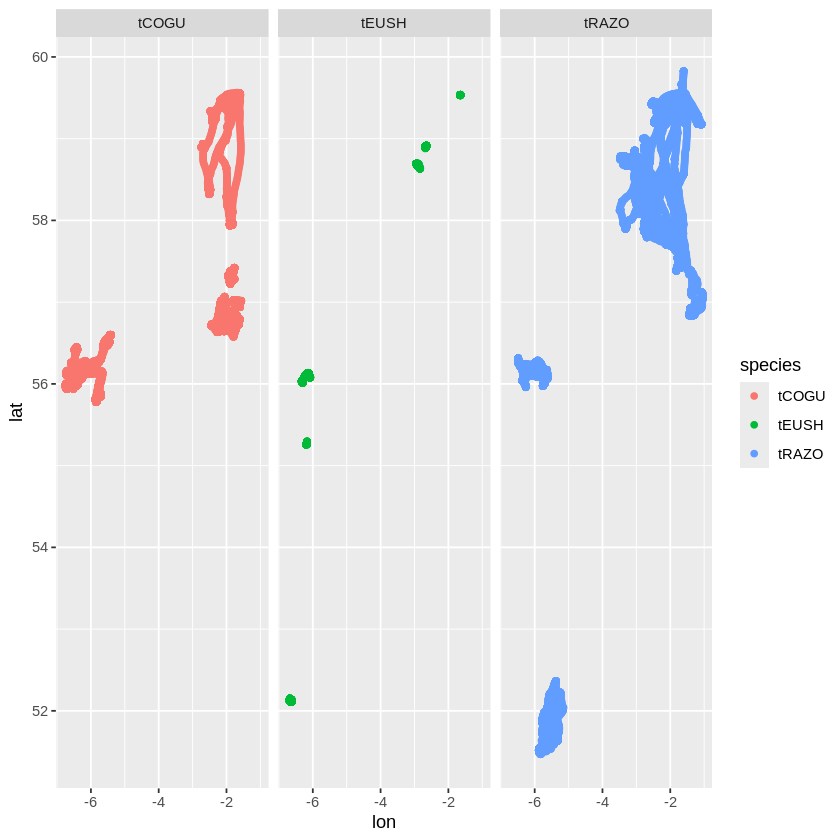

In [4]:
# Quick plot of all tracks, separated by species
ggplot(dat, aes(x = lon, y = lat, group = species, color = species)) +
  geom_point() +
  facet_wrap(~species)

We've got a variety of columns including species (Guillemots [COGU], Shags [EUSH] and Razorbills [RAZO]), bird (the individual), latitude (lat), longitude (lon), altitude (alt), a unix timestamp (unix), the colony (colony2)

Might be nicer to see these on a map...

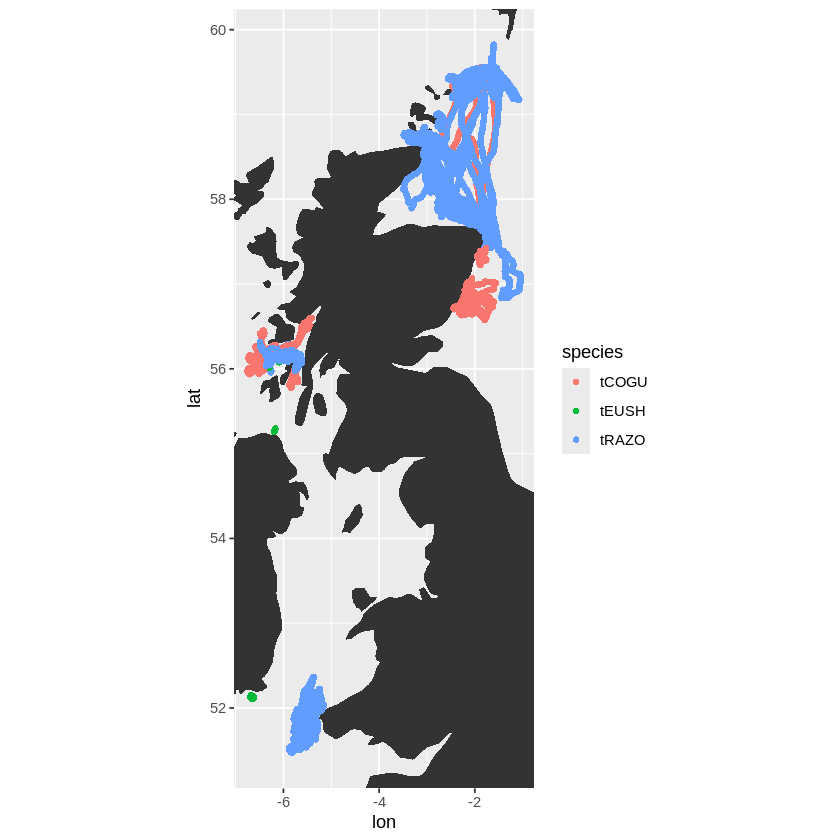

In [5]:
ggplot(dat, aes(lon, lat, color = species, group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16) +
  coord_quickmap() # Sets aspect ratio

Or facetted by species...

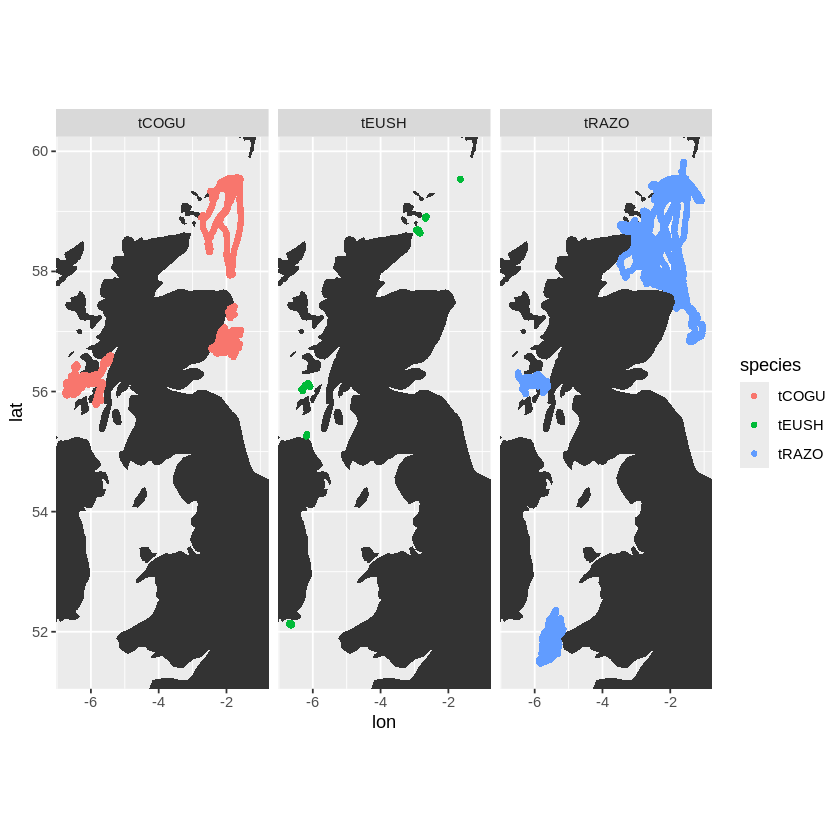

In [6]:
ggplot(dat, aes(lon, lat, color = species, group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16) +
  coord_quickmap() +
  facet_wrap(~species)

How many birds are there for each species at each colony?

In [7]:
dat %>%
  group_by(species, colony2) %>%
  summarise(nbird = n_distinct(bird))

`summarise()` has grouped output by 'species'. You can override using the
`.groups` argument.


species,colony2,nbird
<chr>,<int>,<int>
tCOGU,1,13
tCOGU,2,5
tCOGU,3,7
tCOGU,7,2
tCOGU,10,4
tEUSH,1,2
tEUSH,2,2
tEUSH,4,2
tEUSH,6,5


## Metrics/Features

## Speed

One useful metric for thinking about tracking data is the speed with which an individual is moving.
When moving slowly we may think it is behaving differently from when is moving quickly (e.g. resting vs commuting).
Let's calculate speed for all individuals.

Calculate speed for every individual...

In [8]:
# Function to calculate speed as dist in m / time
haversine_speed <- function(lat2, lat1, long2, long1, time2, time1) {
  dist_in_m = geosphere::distHaversine(
    cbind(long1, lat1),
    cbind(long2, lat2),
    r = 6378137
  )
  timediff <- time2 - time1
  return(dist_in_m / timediff)
}

# Apply that function to each individual, arranged by time, along the lagged positions
dat_with_speed = dat %>%
  group_by(bird) %>%
  arrange(bird, unix) %>%
  mutate(
    speed_ms = haversine_speed(lat, lag(lat), lon, lag(lon), unix, lag(unix))
  )

Have a quick look at the speeds..

In [9]:
head(dat_with_speed$speed_ms)

[1]        NA 0.2717895 0.4699936 0.4015479 0.3617402 0.2847791

Plot the speed distributions...

Warning message:
“Removed 108 rows containing non-finite outside the scale range (`stat_bin()`).”


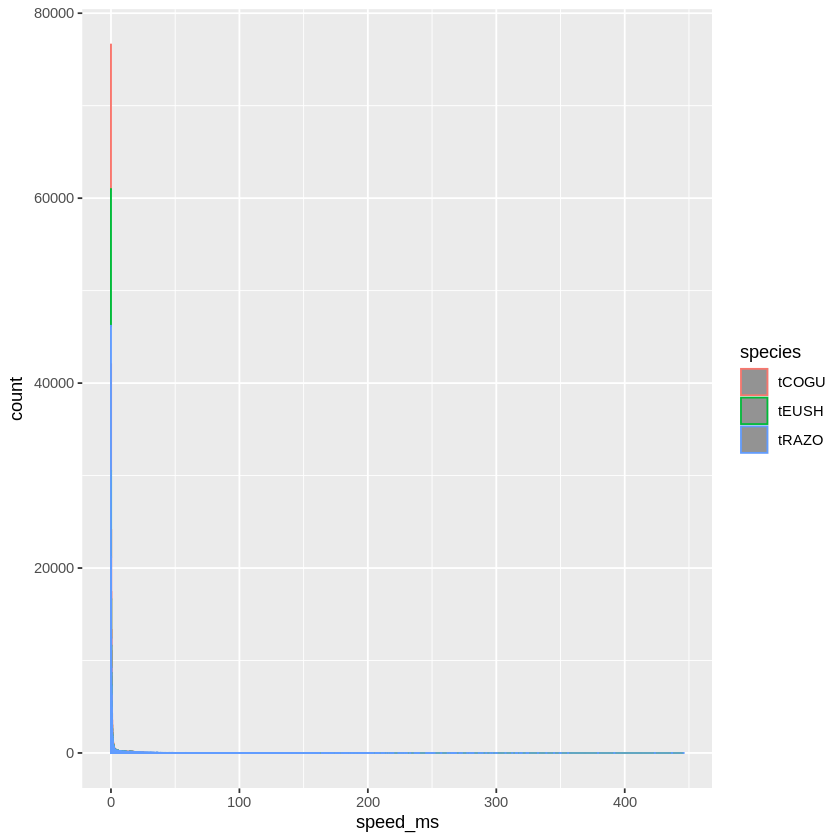

In [10]:
ggplot(dat_with_speed, aes(x = speed_ms, group = species, color = species)) +
  geom_histogram(binwidth = 0.1, alpha = 0.6)

Might be useful to log transform data

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 35153 rows containing non-finite outside the scale range
(`stat_bin()`).”


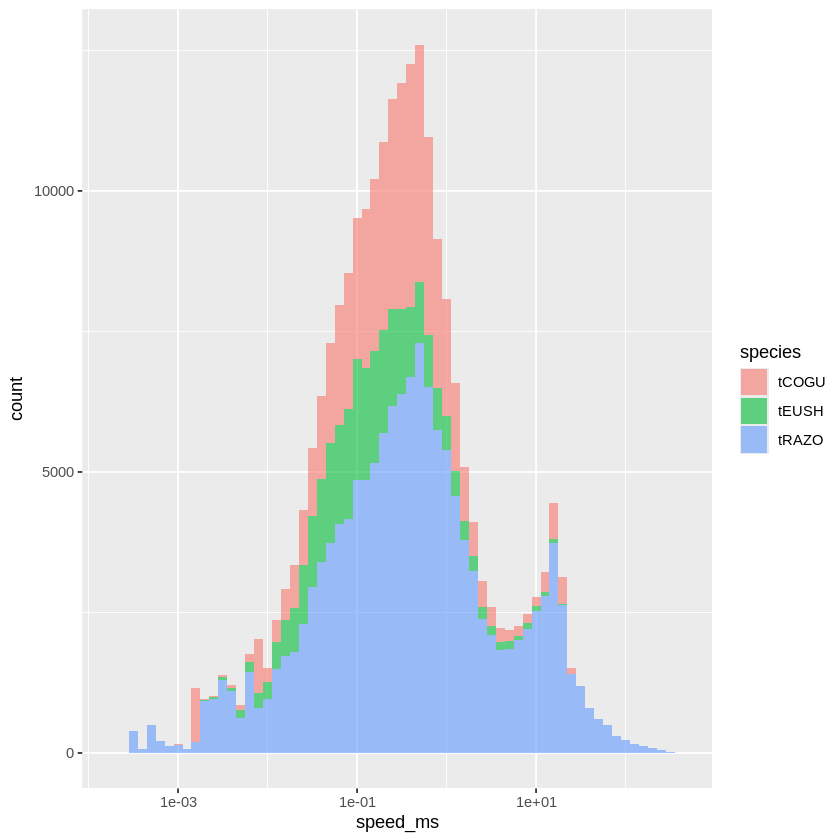

In [11]:
ggplot(dat_with_speed, aes(x = speed_ms, group = species, fill = species)) +
  geom_histogram(binwidth = 0.1, alpha = 0.6) +
  scale_x_log10()

Or split by species

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 35153 rows containing non-finite outside the scale range
(`stat_bin()`).”


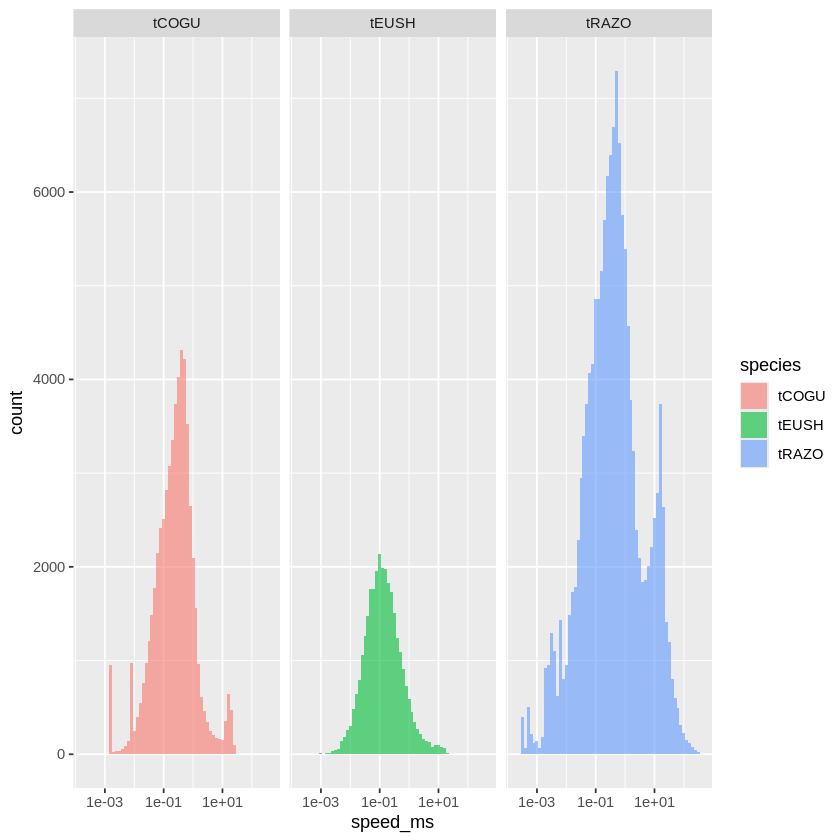

In [12]:
ggplot(dat_with_speed, aes(x = speed_ms, group = species, fill = species)) +
  geom_histogram(binwidth = 0.1, alpha = 0.6) +
  scale_x_log10() +
  facet_wrap(~species)

We could try plotting the tracks with speed to color the positions (to see where they are moving fast/slow)...

Warning message in scale_color_continuous(name = "speed", trans = "log"):
“log-2.718282 transformation introduced infinite values.”


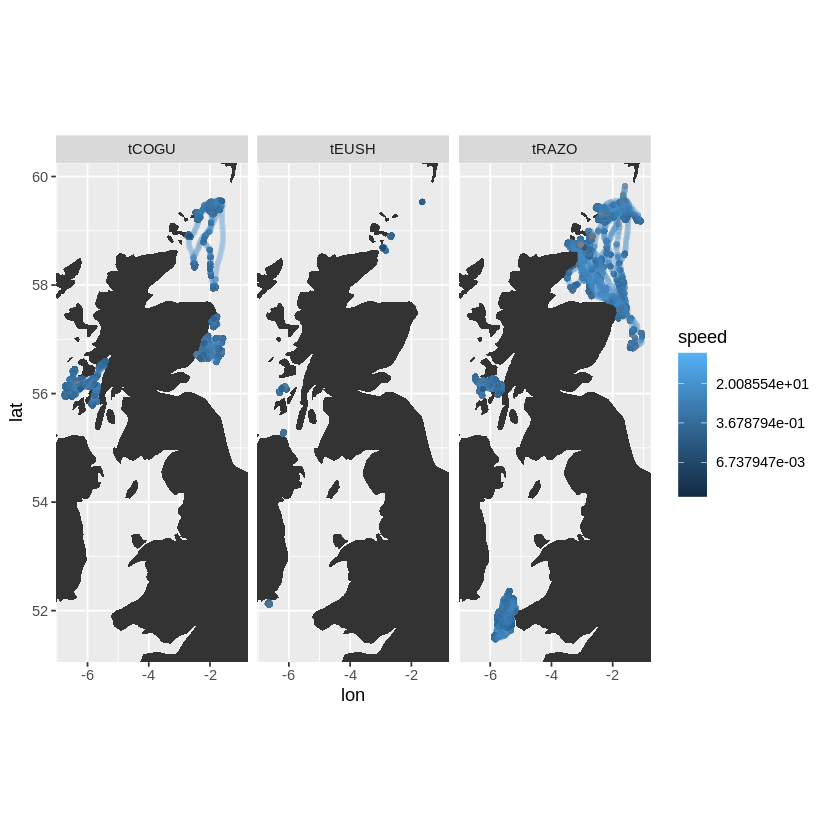

In [13]:
ggplot(dat_with_speed, aes(lon, lat, color = speed_ms, group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16, alpha = 0.1) +
  coord_quickmap() +
  facet_wrap(~species) +
  scale_color_continuous(name = "speed", trans = "log")

...
but it's very hard to discriminate anything at this scale - let's focus on one bird...

Warning message in scale_color_continuous(name = "speed", trans = "log"):
“log-2.718282 transformation introduced infinite values.”


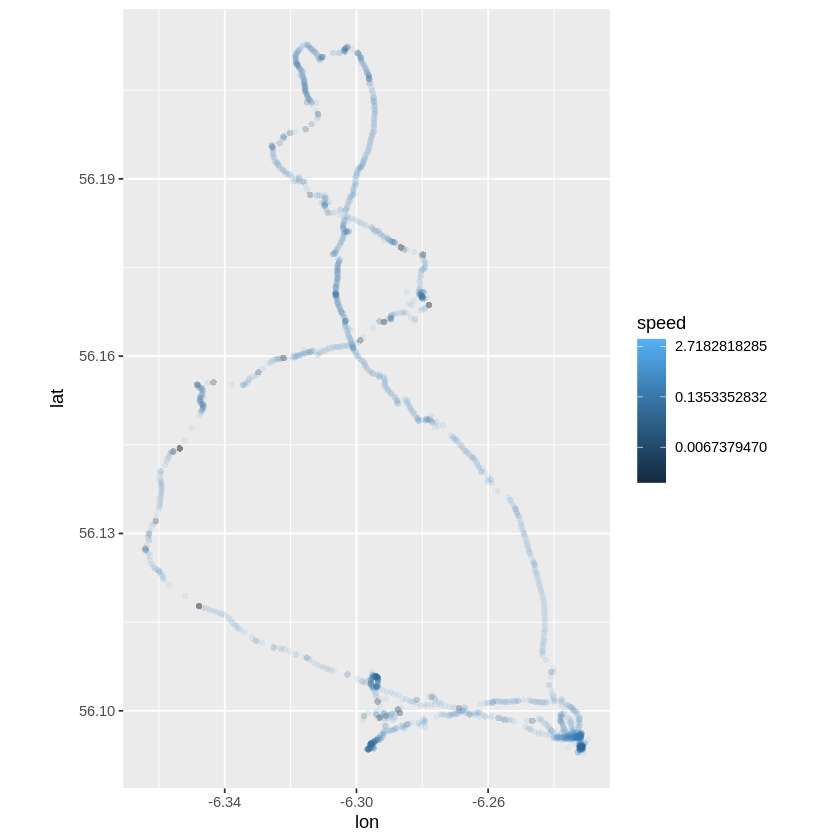

In [14]:
one_bird = subset(dat_with_speed, bird == 1)

ggplot(one_bird, aes(lon, lat, color = speed_ms, group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16, alpha = 0.1) +
  coord_quickmap() +
  scale_color_continuous(name = "speed", trans = "log")

Here we can see some faster (lighter) locations and some slower (darker) locations, possibly where the bird is resting?

Let's have a look at it's speed distribution

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 211 rows containing non-finite outside the scale range (`stat_bin()`).”


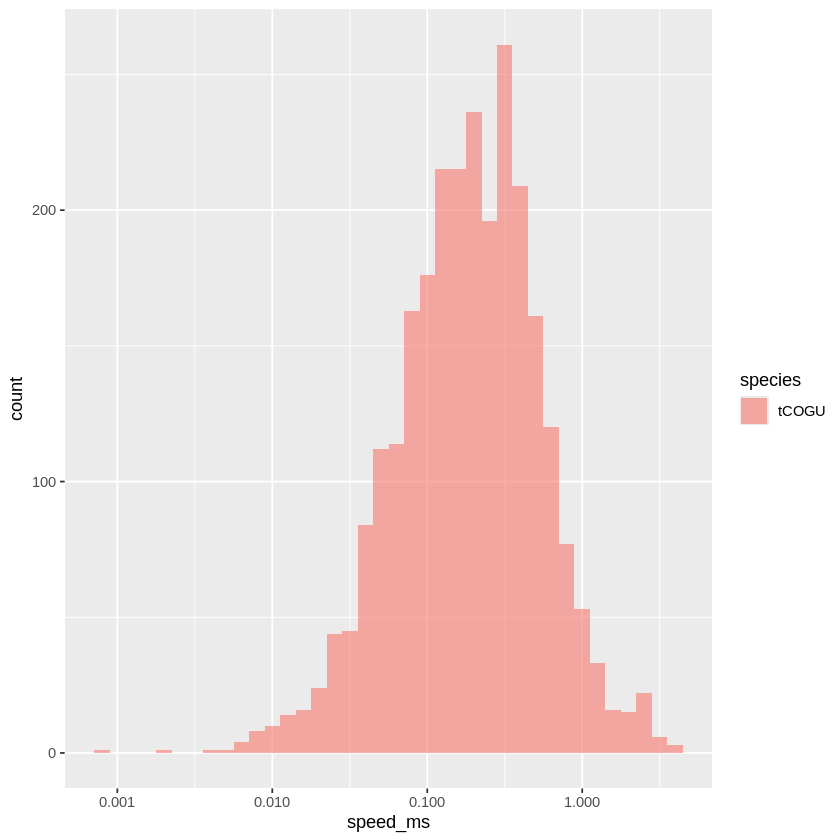

In [15]:
# Might be useful to log transform data
ggplot(one_bird, aes(x = speed_ms, group = species, fill = species)) +
  geom_histogram(binwidth = 0.1, alpha = 0.6) +
  scale_x_log10()

We could try clustering on speed, perhaps using kmeans?

In [16]:
kmeans_result = stats::kmeans(
  log10(na.omit(one_bird$speed_ms) + 1),
  2,
  nstart = 25
)

print(summary(kmeans_result))
print(kmeans_result$center)
print(table(kmeans_result$cluster))

             Length Class  Mode   
cluster      2866   -none- numeric
centers         2   -none- numeric
totss           1   -none- numeric
withinss        2   -none- numeric
tot.withinss    1   -none- numeric
betweenss       1   -none- numeric
size            2   -none- numeric
iter            1   -none- numeric
ifault          1   -none- numeric
        [,1]
1 0.06278579
2 0.26739173

   1    2 
2387  479 


Need to consider how many clusters there are...

Lets use the factoextra package to work out how many clusters are most likely....

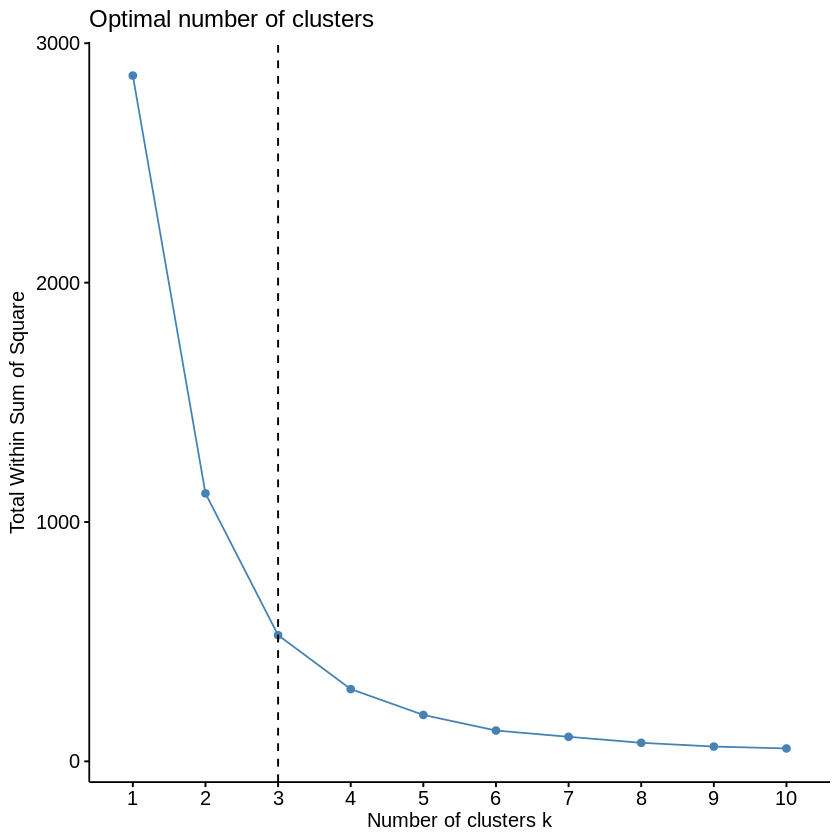

In [17]:
# Dropping NAs (here the first speed)
one_bird$log_speed_ms_s <- scale(log10(one_bird$speed_ms + 1))

library(factoextra)

fviz_nbclust(na.omit(one_bird$log_speed_ms_s), kmeans, method = "wss") +
  geom_vline(xintercept = 3, linetype = 2)

This suggests that (for this bird) 3 clusters might be the best fit, let's rerun kmeans with 3 centres..

In [18]:
kmeans_result = stats::kmeans(
  log10(na.omit(one_bird$speed_ms) + 1),
  3,
  nstart = 25
)

We can then apply these back to the bird data.
Note the appended NA needed as the NA speed (first speed) was dropped above)

In [19]:
one_bird$behaviour = c(NA, kmeans_result$cluster)

And plot these behaviours on the birds track

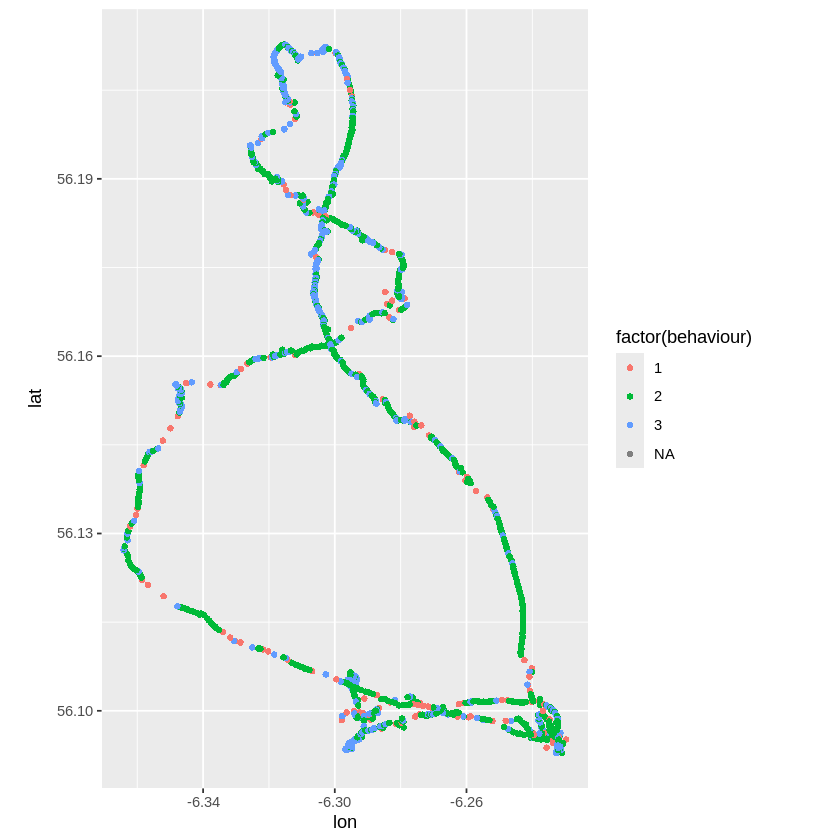

In [20]:
ggplot(one_bird, aes(lon, lat, color = factor(behaviour), group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16) +
  coord_quickmap()

## Metrics - tortuosity

Tortuosity or straightness, can be calculated in a number of ways.
Here we're going to use turning angles and step-lengths along our paths.

For this, let's lean on one of the many available R packages for analysing tracks (moveHMM)

https://cran.r-project.org/web/packages/moveHMM/vignettes/moveHMM-guide.pdf

We can use the package moveHMM to calculate step-length and turning-angle

In [21]:
data <- prepData(one_bird, type = "LL", coordNames = c("lon", "lat"))

Warning message in prepData(one_bird, type = "LL", coordNames = c("lon", "lat")):
“There are 13 missing covariate values. Each will be replaced by the closest available value.”


Quick plot of the track with step-length and turning-angle calculated by moveHMM

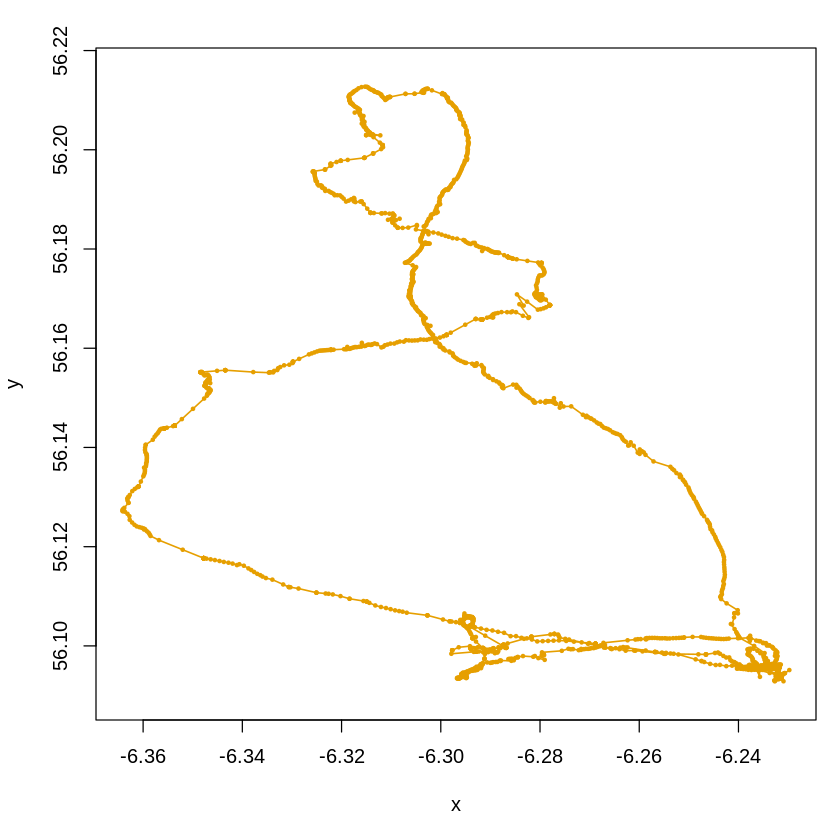

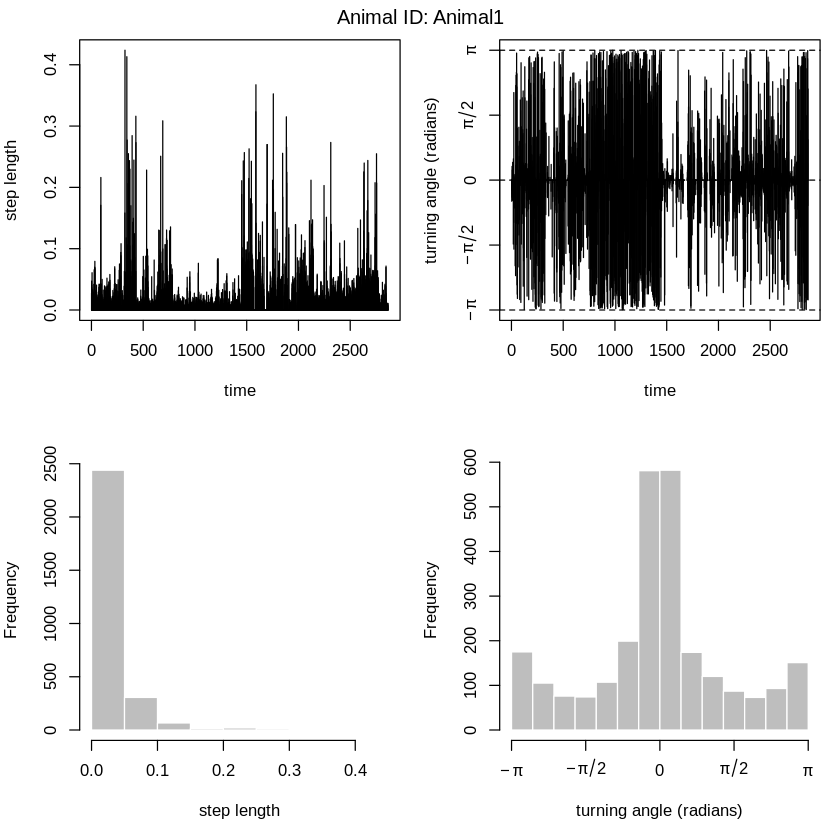

In [22]:
plot(data, compact = TRUE, ask = FALSE)

### Trajectory straightness index, E-max

(from https://github.com/JimMcL/trajr/blob/master/R/straightness.R)

Emax, the maximum expected displacement, is a single-valued measure of straightness defined by (Cheung, Zhang, Stricker, & Srinivasan, 2007).
Emax-a is a dimensionless, scale-independent measure of the maximum possible expected displacement.
Emax-b is \code{Emax-a * mean step length}, and gives the maximum possible expected displacement in spatial units.
Values closer to 0 are *more\* sinuous, while larger values (approaching infinity) are straighter.

Calculate the strightness index (e-max) by calculating the mean cos(turning_angle) and the mean step-length within a window (here 20 samples).

In [23]:
data <- data %>%
  mutate(
    mean_angle = frollmean(
      cos(angle),
      n = 20,
      fill = NA,
      align = "left",
      na.rm = TRUE
    ),
    mean_step = frollmean(
      step,
      n = 20,
      fill = NA,
      align = "left",
      na.rm = TRUE
    ),
    emaxb = mean_step * mean_angle / (1 - mean_angle)
  )

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“NaNs produced”


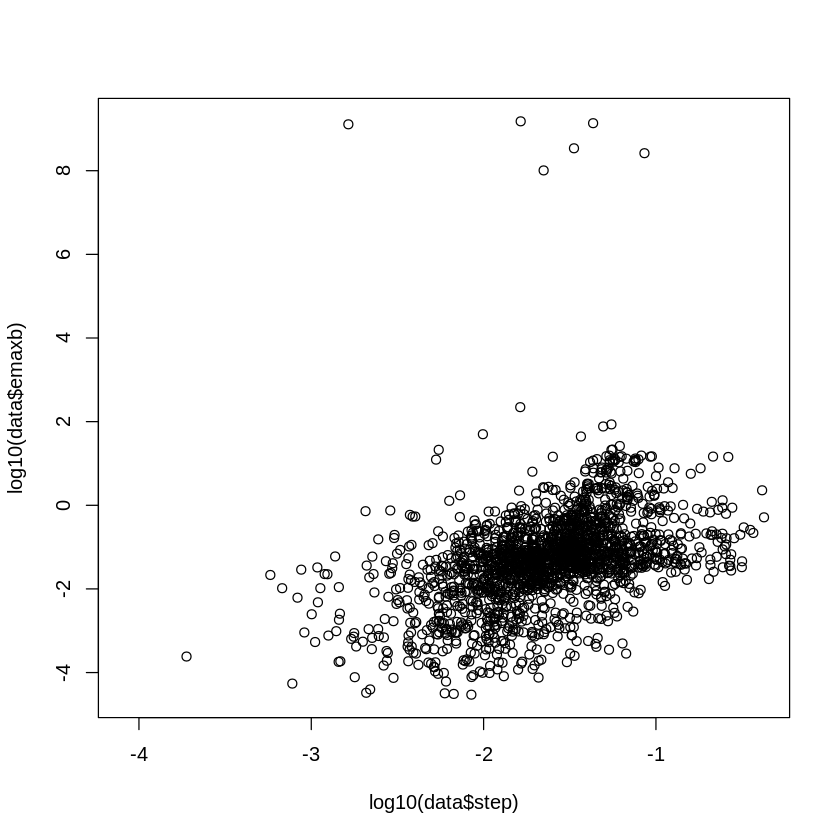

In [24]:
plot(log10(data$step), log10(data$emaxb))

We could now apply kmean to this metric, but let's apply it to speed and straightness together.

Warning message:
“Using one column matrices in `filter()` was deprecated in dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”


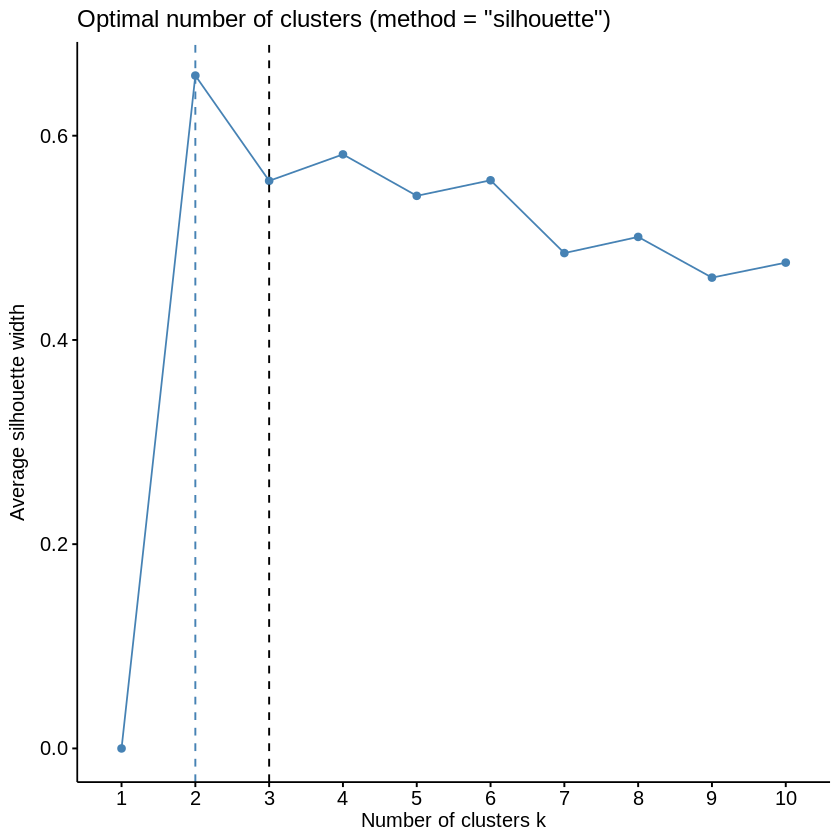

In [25]:
data$log_speed_ms_s <- scale(log10(data$speed_ms + 1))
data$log_emaxb_s <- scale(log10(data$emaxb + 1))

data = filter(data, !is.na(log_emaxb_s))

fviz_nbclust(
  na.omit(cbind(data$log_speed_ms_s, data$log_emaxb_s)),
  kmeans,
  method = "silhouette" # (can also try 'wss', 'silhouette', 'gap_stat')
) +
  geom_vline(xintercept = 3, linetype = 2)

In [26]:
kmeans_result = stats::kmeans(
  na.omit(cbind(data$speed_ms, data$emaxb)),
  3,
  nstart = 25
)

In [27]:
data$behaviour = -1
data$behaviour[complete.cases(data)] = kmeans_result$cluster

Warning message in data$behaviour[complete.cases(data)] = kmeans_result$cluster:
“number of items to replace is not a multiple of replacement length”


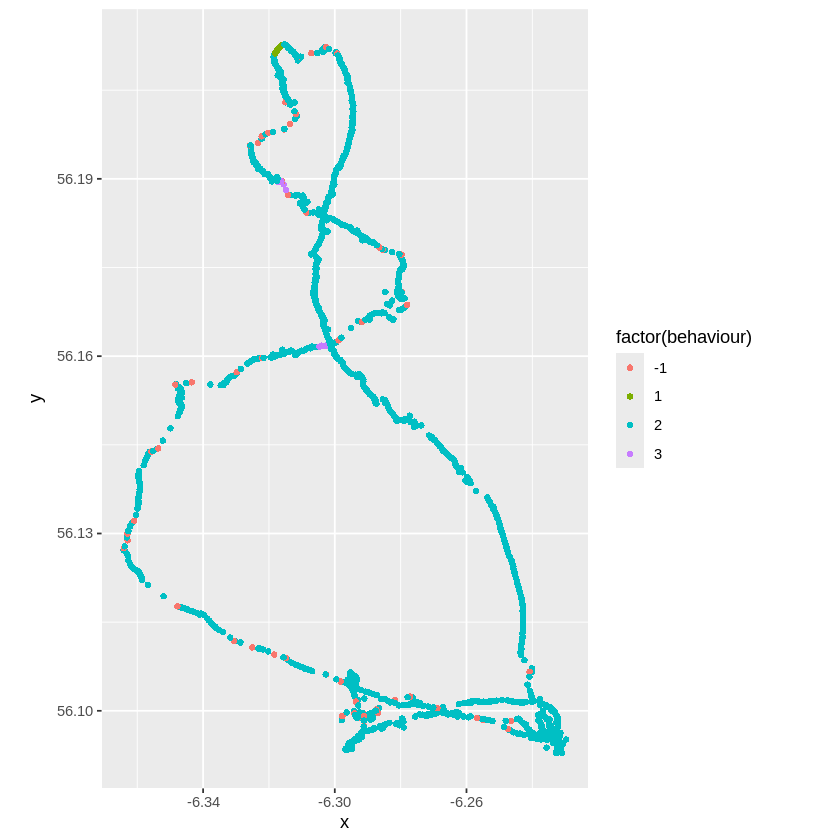

In [28]:
ggplot(data, aes(x, y, color = factor(behaviour), group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16) +
  coord_quickmap()

In [29]:
kmeans_result$centers

1,0.05634217,1203496115.0
2,0.29262945,135729.9
3,0.08419702,297033888.0


# Other metrics?

Can you think/calculate other metrics to include in the models?

# Gaussian mixture models

The same process can be done with a gaussian mixture model (GMM) using the `mclust` package

First we can fit a range of models to the data and see how they compare

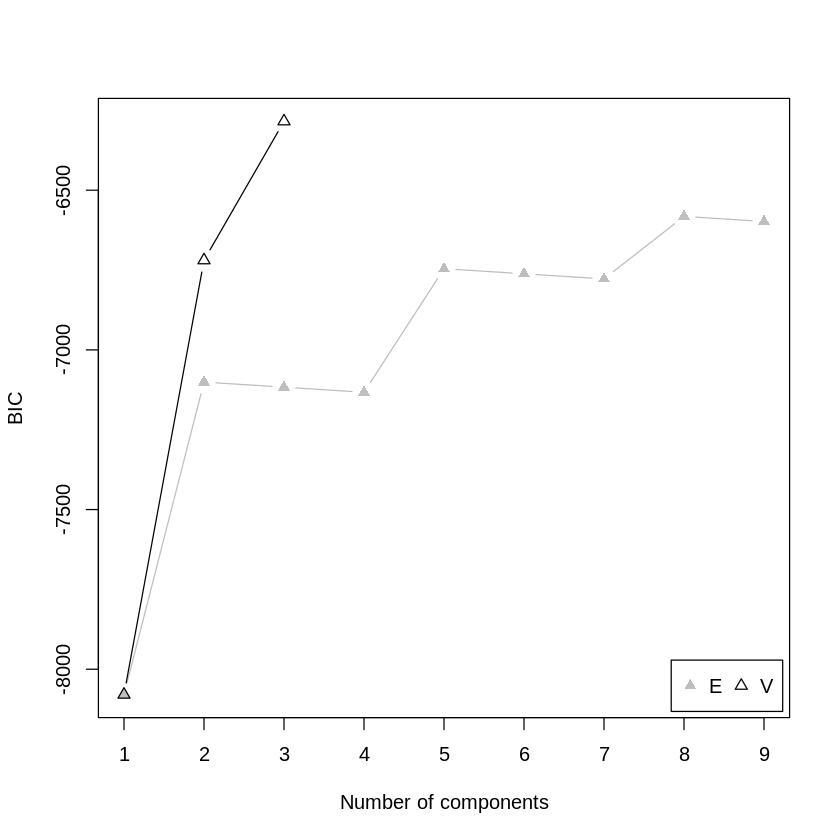

In [30]:
BIC <- mclustBIC(cbind(data$log_speed_ms_s))
plot(BIC)

Then use the results of this to select a model...

In [31]:
# mod1 <- Mclust(cbind(data$log_speed_ms_s, data$log_emaxb_s), x = BIC)
mod1 <- Mclust(data$log_speed_ms_s, x = BIC)
summary(mod1, parameters = TRUE)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust V (univariate, unequal variance) model with 3 components: 

 log-likelihood    n df      BIC       ICL
      -3110.372 2838  8 -6284.35 -7398.268

Clustering table:
   1    2    3 
1300 1303  235 

Mixing probabilities:
        1         2         3 
0.4052224 0.4810913 0.1136863 

Means:
         1          2          3 
-0.6789750  0.1363451  1.9083845 

Variances:
        1         2         3 
0.0513450 0.2927639 2.0412831 

And we can plot the classifications and uncertainty from this model..

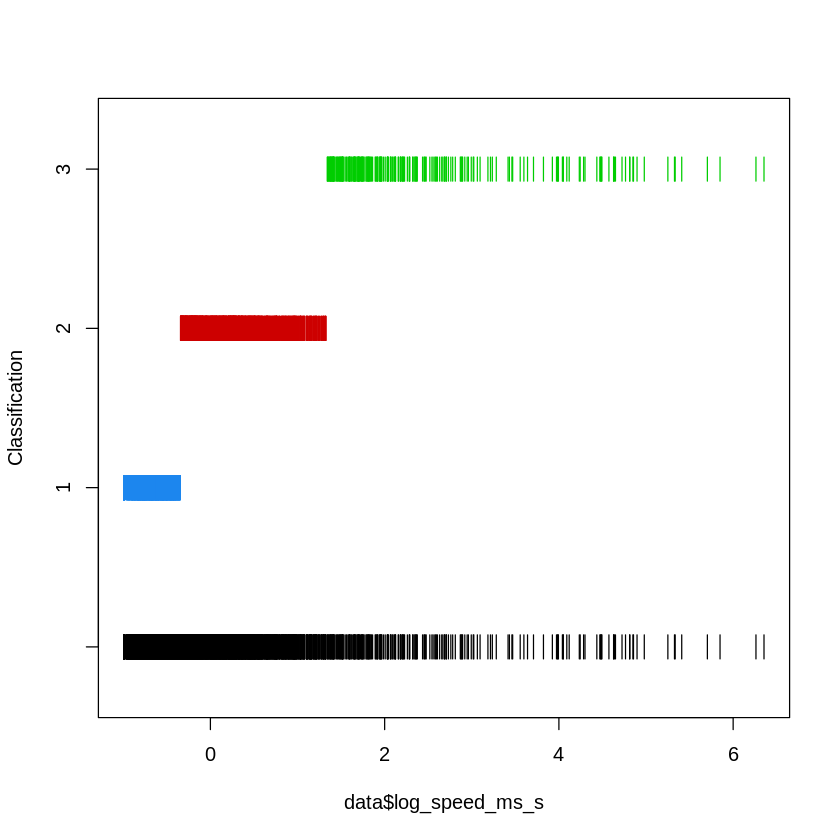

In [32]:
plot(mod1, what = "classification")

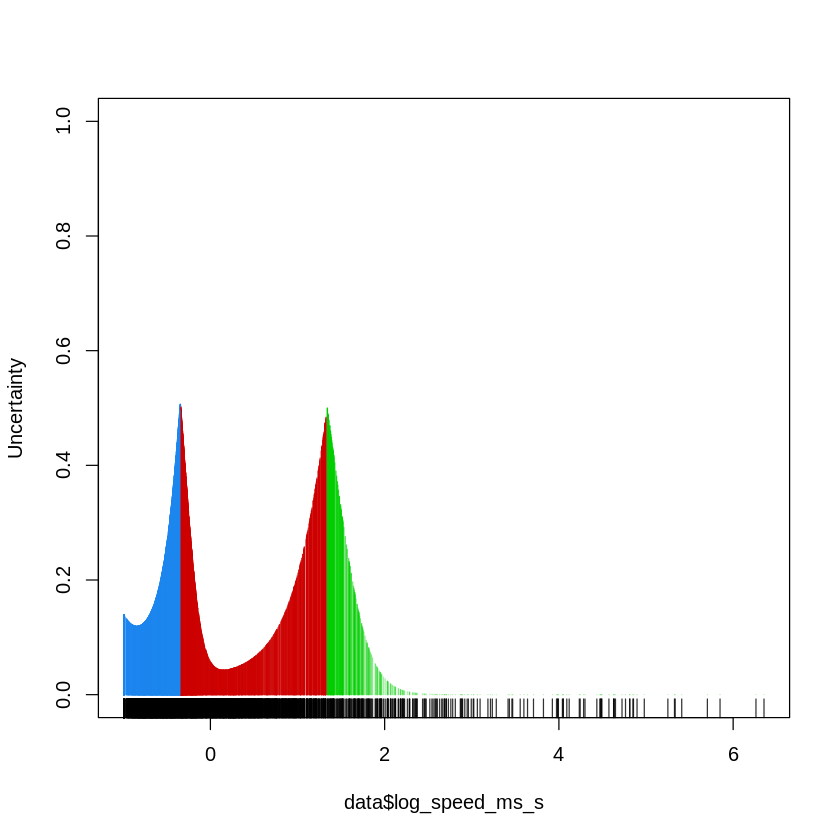

In [33]:
plot(mod1, what = "uncertainty")

We can extract the model classifications and apply them to the trajectory...

In [34]:
data$gmm_behaviour = mod1$classification

And plot the resulting classifications...

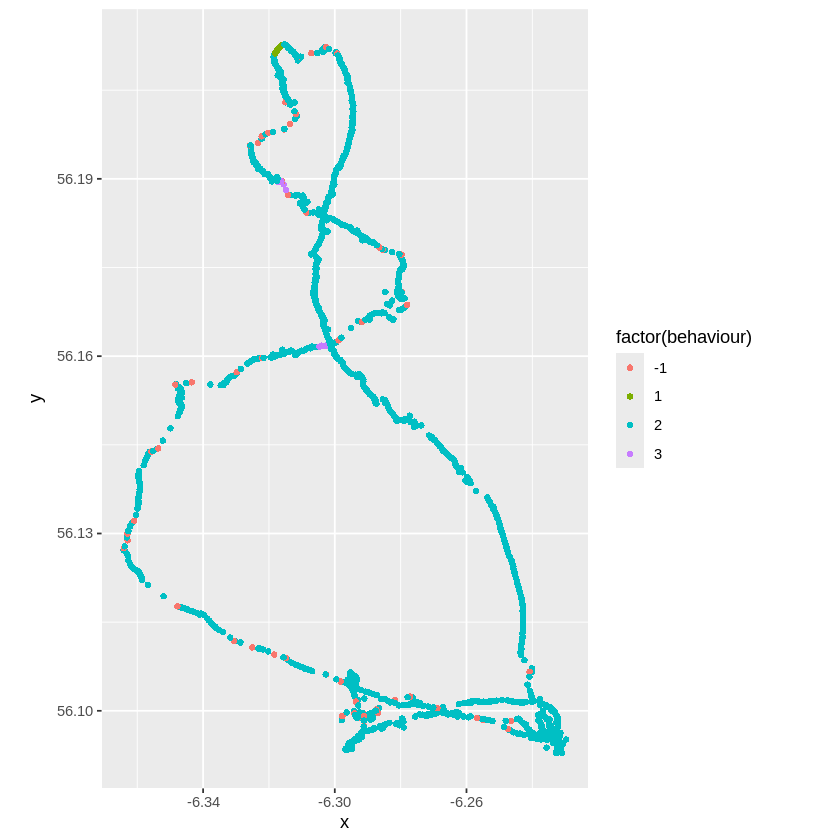

In [35]:
ggplot(data, aes(x, y, color = factor(behaviour), group = species)) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16) +
  coord_quickmap()

Importantly, the GMM is a probabilistic model, we can obtain the probabilities of each sample coming from each class:

In [36]:
head(mod1$z)

7.321388e-03,0.9547832,0.03789541
7.321388e-03,0.9547832,0.03789541
1.632006e-08,0.8979058,0.10209420
2.520369e-06,0.9342813,0.06571620
3.693572e-05,0.9468646,0.05309850
3.675810e-03,0.9570138,0.03931037


And we could then use those to explore locations the model is more confident in

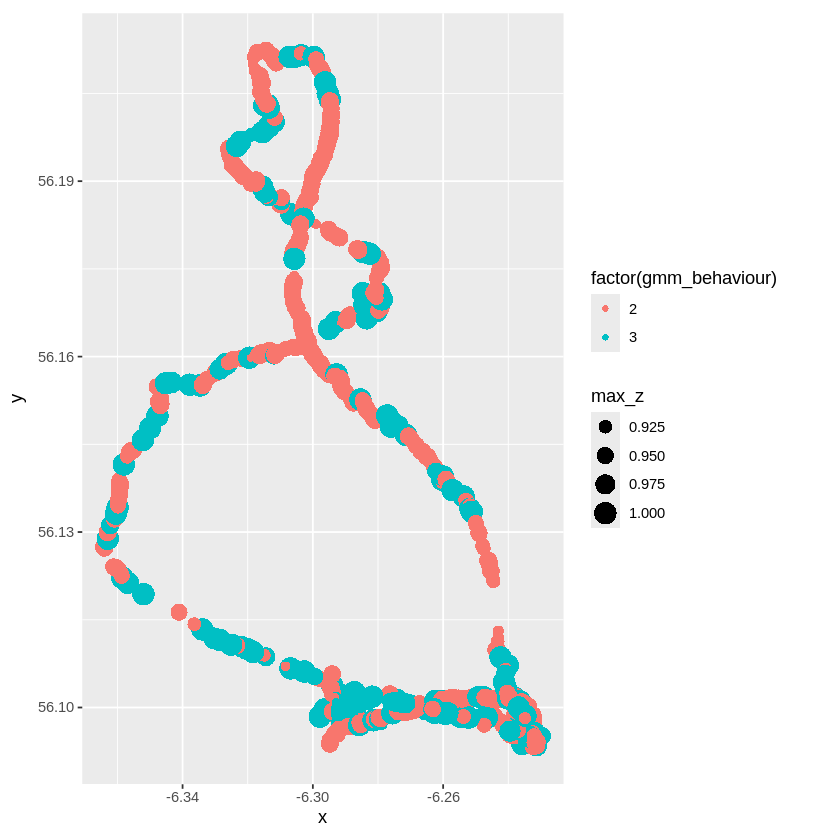

In [37]:
data$max_z = apply(mod1$z, 1, max)

# Filter out classifications with p<0.9
ggplot(
  filter(data, max_z > 0.9),
  aes(x, y, color = factor(gmm_behaviour), group = species, size = max_z)
) +
  annotation_map(map_data("world")) + # Add the map as a base layer before the points
  geom_point(pch = 16) +
  coord_quickmap()

## Hidden Markov Models

We can also fit Hidden-markov models which better capture the temporal dymnamics of a time-series.
These models (or similar 'state-space models') are now frequently used to model animal movement data.
Either to capture behavioural-states (as here) or to estimate errors associated with movement states.

These models simultaneously fit distributions for the metrics we care about (step-length, turning-angle) while also assuming that these distirbutions differ with the animals behaviour.
We can specifiy how many of these 'states' we think there should be and fit a model.

The model will estimate both parameters for the mean/sd of each state, but also the transition probabilities between them (the probability of being in state X/Y at the next iteration, when you are in state X or Y now)T

In [38]:
###
# Hidden Markov Models
###

# Priors

# Starting values for the step length parameters
# initial means (one for each state)
stepMean0 <- c(0.1, 1.0, 1.0)

# initial standard deviations (one for each state) stepPar0 <- c(stepMean0, stepSD0)
stepSD0 <- c(0.1, 0.7, 1.0)

### starting values for step angle distribution parameters
stepPar0 <- c(stepMean0, stepSD0)

# zeromass0 <- c(0.1, 0.05) # step zero-mass

# turning angle mean of each state
angleMean0 <- c(pi, 0, pi)

# angle concentration
kappa0 <- c(0.01, 8, 0.5)

# starting values for the parameters of the turning angle distributions
anglePar0 <- c(angleMean0, kappa0)

## call to fitting function
# ***
# ** One-state model, e.g. a NULL model with no transitions (should be roughly equivalent to a GMM)
# ***
m_1 <- fitHMM(
  data = na.omit(data),
  nbStates = 1,
  stepPar0 = stepPar0[c(1, 4)],
  anglePar0 = anglePar0[c(1, 4)],
  formula = ~1,
)

### get info from model
m_1

Warning message in nlm(f = nLogLike, p = wpar, nbStates = nbStates, bounds = bounds, :
“NA/NaN replaced by maximum positive value”
Warning message in nlm(f = nLogLike, p = wpar, nbStates = nbStates, bounds = bounds, :
“NA/NaN replaced by maximum positive value”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”


Value of the maximum log-likelihood: 2129.937 

Step length parameters:
----------------------
        state 1
mean 0.03013948
sd   0.02866553

Turning angle parameters:
------------------------
                  state 1
mean          -0.01445822
concentration  0.84906590

Initial distribution:
--------------------
[1] 1

Fit a two-state model using two parameters from the stepLength and angle priors

Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”


Value of the maximum log-likelihood: 3066.485 

Step length parameters:
----------------------
        state 1    state 2
mean 0.01977146 0.04932800
sd   0.01812971 0.03677454

Turning angle parameters:
------------------------
                  state 1      state 2
mean          -0.04363389 -0.009921754
concentration  0.16180566 14.023175186

Regression coeffs for the transition probabilities:
--------------------------------------------------
             1 -> 2    2 -> 1
intercept -2.486594 -1.789275

Transition probability matrix:
-----------------------------
          [,1]       [,2]
[1,] 0.9231966 0.07680336
[2,] 0.1431616 0.85683838

Initial distribution:
--------------------
[1] 7.011766e-08 9.999999e-01

Decoding states sequence... DONE


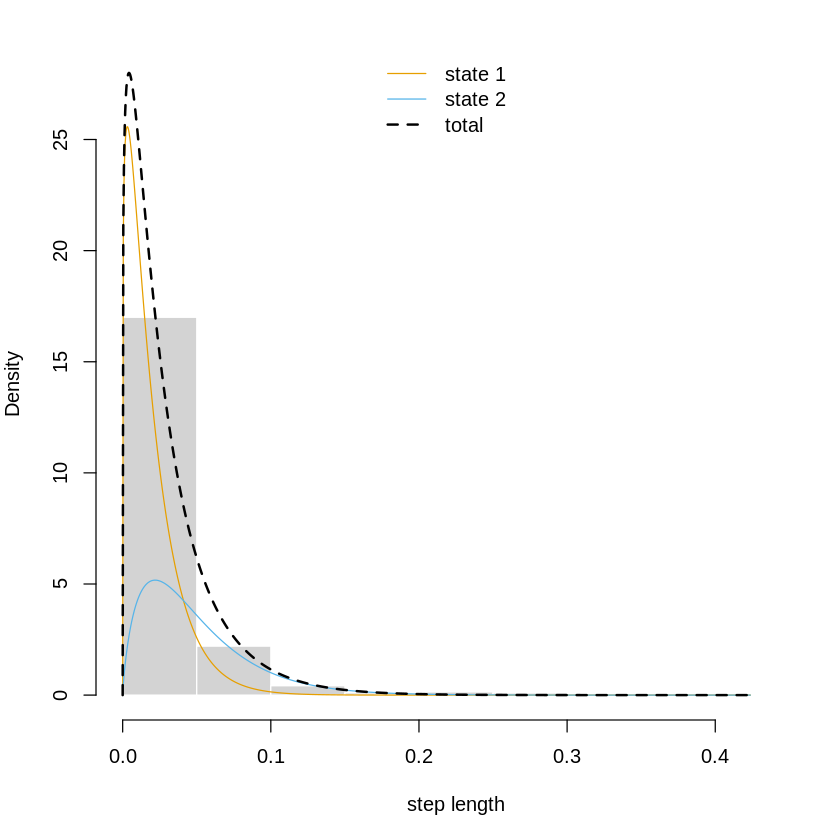

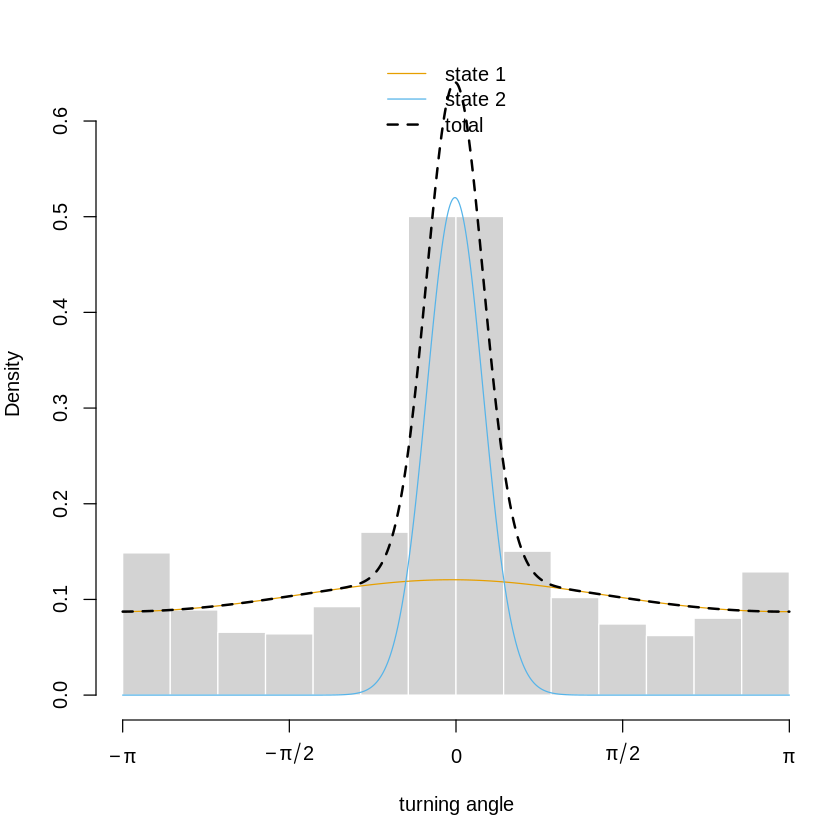

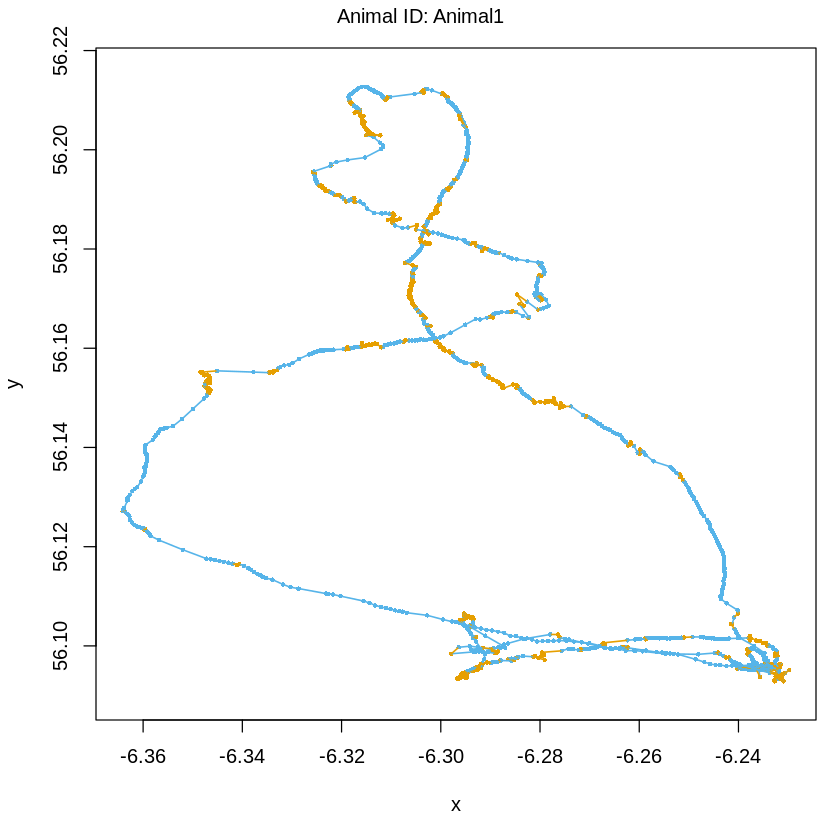

In [39]:
# Note the plotting doesn't work (as 1-state model i think!)
#plot(m_1, plotCI=TRUE, ask = F)

###
# 2-state model
###

## call to fitting function
m_2 <- fitHMM(
  data = na.omit(data),
  nbStates = 2,
  stepPar0 = stepPar0[c(1:2, 4:5)],
  anglePar0 = anglePar0[c(1:2, 4:5)],
  formula = ~1
)

### get info from model
m_2
plot(m_2, plotCI = TRUE, ask = F)

Fit a three-state model using all of the parameters

Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”
Warning message in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L):
“number of columns of result is not a multiple of vector length (arg 2)”


Value of the maximum log-likelihood: 3066.485 

Step length parameters:
----------------------
        state 1    state 2      state 3
mean 0.01977145 0.04932802 5.603842e+13
sd   0.01812970 0.03677456 6.179046e-17

Turning angle parameters:
------------------------
                  state 1      state 2    state 3
mean          -0.04363563 -0.009922038 -2.1376007
concentration  0.16180515 14.023120974  0.6773532

Regression coeffs for the transition probabilities:
--------------------------------------------------
             1 -> 2   1 -> 3    2 -> 1    2 -> 3   3 -> 1    3 -> 2
intercept -2.486593 -55.2259 -1.789275 -77.32486 4.376854 0.8197573

Transition probability matrix:
-----------------------------
          [,1]       [,2]         [,3]
[1,] 0.9231966 0.07680340 9.571711e-25
[2,] 0.1431616 0.85683842 2.244595e-34
[3,] 0.9605351 0.02739592 1.206896e-02

Initial distribution:
--------------------
[1] 2.400499e-07 9.999998e-01 1.497779e-09

Decoding states sequence... DONE


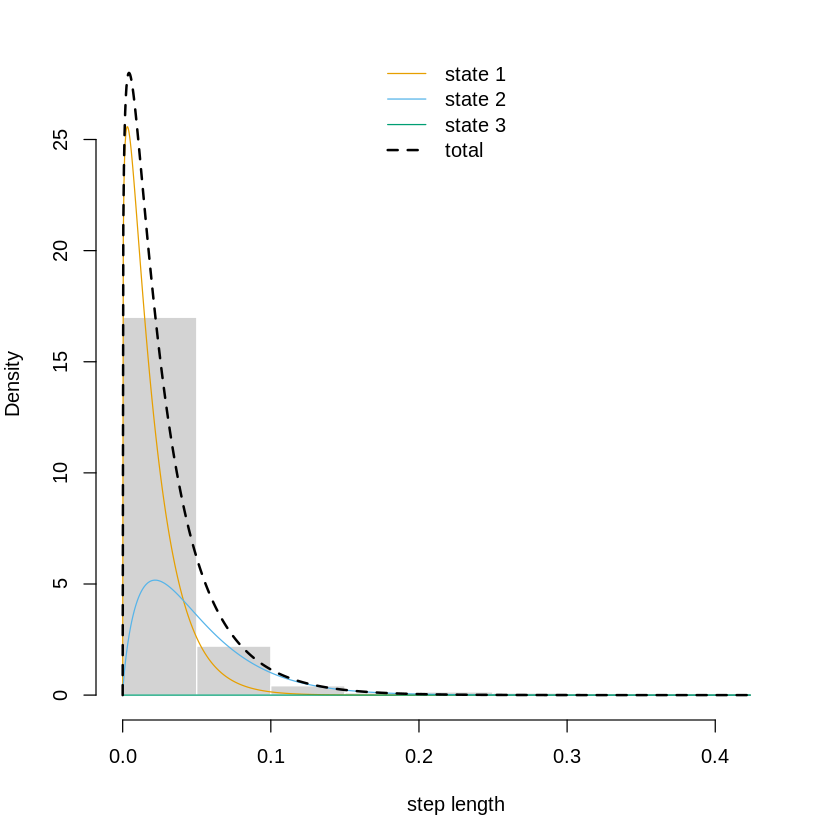

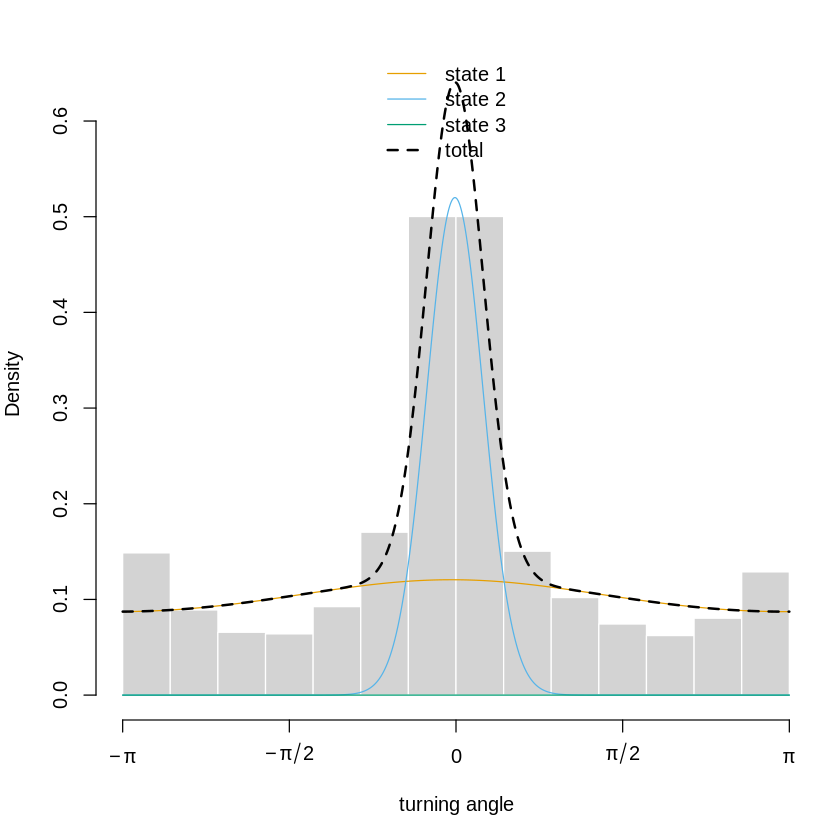

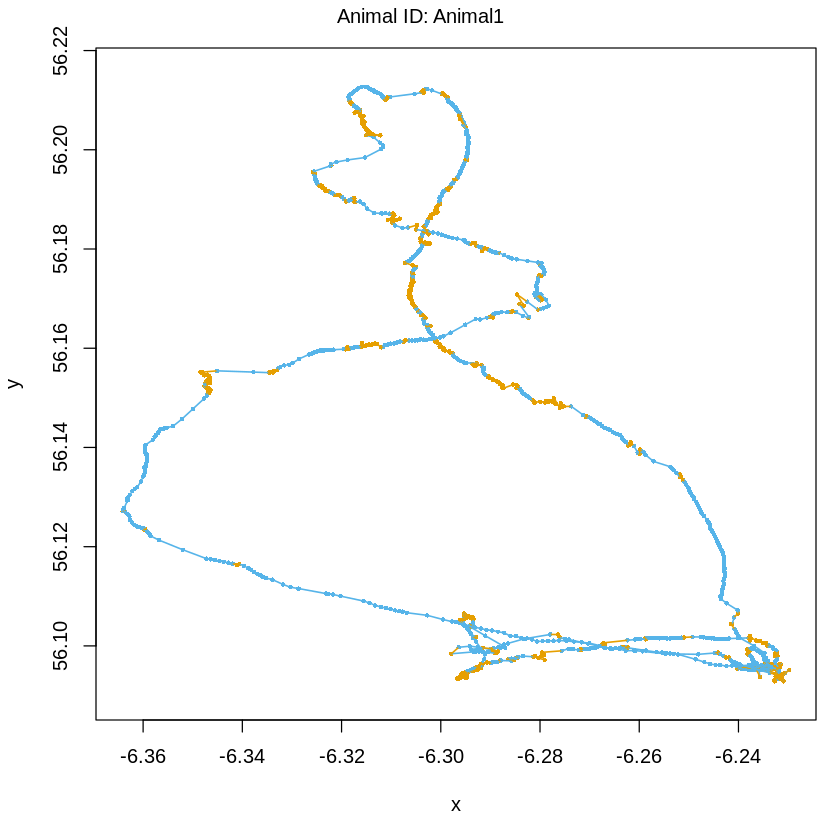

In [41]:
###
# 3-state model
###

## call to fitting function
m_3 <- fitHMM(
  data = na.omit(data),
  nbStates = 3,
  stepPar0 = stepPar0,
  anglePar0 = anglePar0,
  formula = ~1
)

### get info from model
m_3
plot(m_3, plotCI = TRUE, ask = F)

And compare the AIC of each model (lower is better)

In [42]:
# Compare AICs - here a 2-state model is favoured
AIC(m_1, m_2, m_3)

Model,AIC
<chr>,<dbl>
m_2,-6110.971
m_3,-6092.971
m_1,-4251.874


Look at the summary output for the HMM. What do you think the 'transition probabilities' are?
How could we use these probabilities?

## Some further things to try

### Other birds

- Can you apply a classification to all of the individuals from one colony/species?
- How do the number of states differ between individuals (does this change if run the models across all of them individually/together?)

### HMMs on haggis

There's a walk through of how to apply an HMM to 'Haggis' tracks here:
https://cran.r-project.org/web/packages/moveHMM/vignettes/moveHMM-example.pdf

### Accleration data

- You could try applying these to the acceleration data we collected previously, that data is here:
  https://www.dropbox.com/s/8p1v0xzvuy1q0qf/all_csv_data_msc_datascience_2023.csv.zip?dl=0 (45Mb compressed, uncompresses to 700Mb)

### Deep learning

- In Browning et al (2018), we were able to predict dives using just the lat/lon data - can you predict dives using these data?
- To constuct matrices for predictions, we used an embedding matrix (a matrix where each row is from a different time point across a rolling window).
  In `r`, you can construct these using `embed`
- Can you predict `species` using the movement data?